In [8]:
#Task 1 - Load & Inspect the Data 

import pandas as pd

df = pd.read_csv("small_business_invoice_late_payment_dataset.csv")

df.head()

,invoice_id,client_age,age_group,gender,region,client_type,industry,contract_type,invoice_amount,payment_terms_days,previous_late_invoices,number_of_previous_invoices,days_since_last_invoice,client_satisfaction_score,reminder_emails_sent,auto_payment_enabled,invoice_paid_late
0,INV0001,30,26-35,Male,West,Returning,Consulting,Monthly,3002.79,7,0,46,97,3,1,No,0
1,INV0002,58,51+,Male,South,New,Retail,Monthly,1066.94,14,3,42,183,8,2,Yes,0
2,INV0003,57,51+,Male,East,Returning,Construction,Monthly,13259.39,30,1,13,220,9,1,Yes,0
3,INV0004,73,51+,Female,East,New,Consulting,Annual,21592.55,7,0,49,303,1,6,Yes,0
4,INV0005,54,51+,Male,South,Returning,Healthcare,One-time,6231.79,7,0,4,506,1,1,No,0


In [9]:
df.shape

(370, 17)

In [10]:
df.columns

Index(['invoice_id', 'client_age', 'age_group', 'gender', 'region',
       'client_type', 'industry', 'contract_type', 'invoice_amount',
       'payment_terms_days', 'previous_late_invoices',
       'number_of_previous_invoices', 'days_since_last_invoice',
       'client_satisfaction_score', 'reminder_emails_sent',
       'auto_payment_enabled', 'invoice_paid_late'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 370 entries, 0 to 369
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   invoice_id                   370 non-null    object 
 1   client_age                   370 non-null    int64  
 2   age_group                    370 non-null    object 
 3   gender                       370 non-null    object 
 4   region                       370 non-null    object 
 5   client_type                  370 non-null    object 
 6   industry                     370 non-null    object 
 7   contract_type                370 non-null    object 
 8   invoice_amount               361 non-null    float64
 9   payment_terms_days           370 non-null    int64  
 10  previous_late_invoices       370 non-null    int64  
 11  number_of_previous_invoices  370 non-null    int64  
 12  days_since_last_invoice      370 non-null    int64  
 13  client_satisfaction_

In [11]:
df.isnull().sum()

invoice_id                     0
client_age                     0
age_group                      0
gender                         0
region                         0
client_type                    0
industry                       0
contract_type                  0
invoice_amount                 9
payment_terms_days             0
previous_late_invoices         0
number_of_previous_invoices    0
days_since_last_invoice        0
client_satisfaction_score      0
reminder_emails_sent           0
auto_payment_enabled           0
invoice_paid_late              0
dtype: int64

In [12]:
df["invoice_paid_late"].value_counts()

invoice_paid_late
0    217
1    153
Name: count, dtype: int64

In [13]:
df["invoice_paid_late"].value_counts(normalize=True) * 100

invoice_paid_late
0    58.648649
1    41.351351
Name: proportion, dtype: float64

In [14]:
#Task 3 - Data Preprocessing

df = df.dropna(subset=['invoice_amount'])

In [15]:
print(df.isnull().sum())

invoice_id                     0
client_age                     0
age_group                      0
gender                         0
region                         0
client_type                    0
industry                       0
contract_type                  0
invoice_amount                 0
payment_terms_days             0
previous_late_invoices         0
number_of_previous_invoices    0
days_since_last_invoice        0
client_satisfaction_score      0
reminder_emails_sent           0
auto_payment_enabled           0
invoice_paid_late              0
dtype: int64


In [16]:
y = df["invoice_paid_late"]

X = df.drop(columns=["invoice_id", "invoice_paid_late"])

X.head()

,client_age,age_group,gender,region,client_type,industry,contract_type,invoice_amount,payment_terms_days,previous_late_invoices,number_of_previous_invoices,days_since_last_invoice,client_satisfaction_score,reminder_emails_sent,auto_payment_enabled
0,30,26-35,Male,West,Returning,Consulting,Monthly,3002.79,7,0,46,97,3,1,No
1,58,51+,Male,South,New,Retail,Monthly,1066.94,14,3,42,183,8,2,Yes
2,57,51+,Male,East,Returning,Construction,Monthly,13259.39,30,1,13,220,9,1,Yes
3,73,51+,Female,East,New,Consulting,Annual,21592.55,7,0,49,303,1,6,Yes
4,54,51+,Male,South,Returning,Healthcare,One-time,6231.79,7,0,4,506,1,1,No


In [17]:
fairness_columns = df[["age_group", "gender", "region"]]

X = X.drop(columns=["age_group", "gender", "region"])

X.head()

,client_age,client_type,industry,contract_type,invoice_amount,payment_terms_days,previous_late_invoices,number_of_previous_invoices,days_since_last_invoice,client_satisfaction_score,reminder_emails_sent,auto_payment_enabled
0,30,Returning,Consulting,Monthly,3002.79,7,0,46,97,3,1,No
1,58,New,Retail,Monthly,1066.94,14,3,42,183,8,2,Yes
2,57,Returning,Construction,Monthly,13259.39,30,1,13,220,9,1,Yes
3,73,New,Consulting,Annual,21592.55,7,0,49,303,1,6,Yes
4,54,Returning,Healthcare,One-time,6231.79,7,0,4,506,1,1,No


In [18]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,client_age,invoice_amount,payment_terms_days,previous_late_invoices,number_of_previous_invoices,days_since_last_invoice,client_satisfaction_score,reminder_emails_sent,client_type_Long-term,client_type_New,client_type_Returning,industry_Consulting,industry_Education,industry_Healthcare,industry_Retail,industry_Technology,contract_type_Monthly,contract_type_One-time,auto_payment_enabled_Yes
0,30,3002.79,7,0,46,97,3,1,False,False,True,True,False,False,False,False,True,False,False
1,58,1066.94,14,3,42,183,8,2,False,True,False,False,False,False,True,False,True,False,True
2,57,13259.39,30,1,13,220,9,1,False,False,True,False,False,False,False,False,True,False,True
3,73,21592.55,7,0,49,303,1,6,False,True,False,True,False,False,False,False,False,False,True
4,54,6231.79,7,0,4,506,1,1,False,False,True,False,False,True,False,False,False,True,False


In [19]:
#Task 4 - Train Test Split 

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, fairness_train, fairness_test = train_test_split(
    X,
    y,
    fairness_columns,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (288, 19)
X_test shape: (73, 19)
y_train shape: (288,)
y_test shape: (73,)


In [20]:
#Task 5 - Train a Classification Model 

from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=4, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual Late Invoice Payment": y_test.values,
    "Predicted Late Invoice Payment": y_pred
})

comparison.head(10)

,Actual Late Invoice Payment,Predicted Late Invoice Payment
0,0,0
1,1,0
2,0,0
3,0,0
4,1,1
5,1,1
6,1,1
7,0,0
8,0,0
9,1,1


In [21]:
#Task 6 - Evaluate the Model 

from sklearn.metrics import accuracy_score

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred)

evaluation_results = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})

evaluation_results

,Dataset,Accuracy
0,Training Data,0.833333
1,Testing Data,0.726027


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_test_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_test_pred)

precision = precision_score(y_test, y_test_pred, zero_division=0)

recall = recall_score(y_test, y_test_pred, zero_division=0)

f1 = f1_score(y_test, y_test_pred, zero_division=0)

metrics_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics_results

,Metric,Score
0,Accuracy,0.726027
1,Precision,0.678571
2,Recall,0.633333
3,F1-Score,0.655172


In [23]:
#Task 7 - Confusion Matrix 

from sklearn.metrics import confusion_matrix

from sklearn.metrics import ConfusionMatrixDisplay

import matplotlib.pyplot as plt

y_test_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

cm_table = pd.DataFrame(
    cm,
    index=["Actual Not Late Payments (0)", "Actual Late Payments (1)"],
    columns=["Predicted Not Late Payments (0)", "Predicted Late Payments (1)"]
)

cm_table

,Predicted Not Late Payments (0),Predicted Late Payments (1)
Actual Not Late Payments (0),34,9
Actual Late Payments (1),11,19


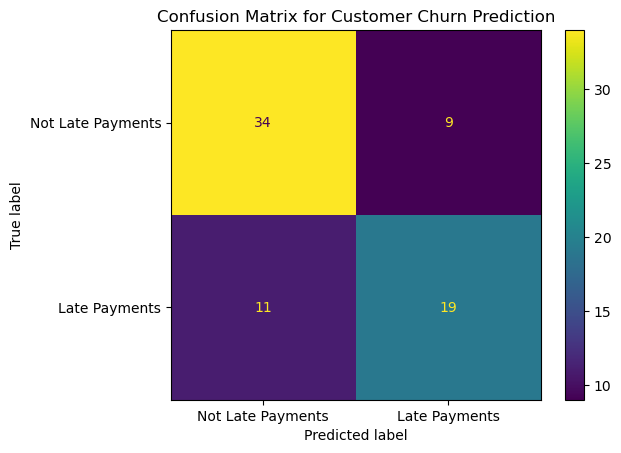

In [24]:
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Late Payments", "Late Payments"]
)

display.plot()

plt.title("Confusion Matrix for Customer Churn Prediction")

plt.show()

In [25]:
#Task 8 - Error Analysis 

y_test_pred = model.predict(X_test)

error_analysis = pd.DataFrame({
    "Invoice ID": df.loc[y_test.index, "invoice_id"].values,
    "Actual Late Payments": y_test.values,
    "Predicted Late Payments": y_test_pred
})

error_analysis["Correct Prediction"] = error_analysis["Actual Late Payments"] == error_analysis["Predicted Late Payments"]

error_analysis.head(10)

,Invoice ID,Actual Late Payments,Predicted Late Payments,Correct Prediction
0,INV0346,0,0,True
1,INV0207,1,0,False
2,INV0128,0,0,True
3,INV0223,0,0,True
4,INV0230,1,1,True
5,INV0147,1,1,True
6,INV0290,1,1,True
7,INV0190,0,0,True
8,INV0193,0,0,True
9,INV0362,1,1,True


In [26]:
def classify_error(row):
    
    if row["Actual Late Payments"] == 0 and row["Predicted Late Payments"] == 0: 
        return "True Negative"
    elif row["Actual Late Payments"] == 0 and row["Predicted Late Payments"] == 1: 
        return "False Positive"
    elif row["Actual Late Payments"] == 1 and row["Predicted Late Payments"] == 0:
        return "False Negative"
    elif row["Actual Late Payments"] == 1 and row["Predicted Late Payments"] == 1:
        return "True Positive"
    
error_analysis["Error Type"] = error_analysis.apply(classify_error, axis=1)

error_analysis.head(10)

,Invoice ID,Actual Late Payments,Predicted Late Payments,Correct Prediction,Error Type
0,INV0346,0,0,True,True Negative
1,INV0207,1,0,False,False Negative
2,INV0128,0,0,True,True Negative
3,INV0223,0,0,True,True Negative
4,INV0230,1,1,True,True Positive
5,INV0147,1,1,True,True Positive
6,INV0290,1,1,True,True Positive
7,INV0190,0,0,True,True Negative
8,INV0193,0,0,True,True Negative
9,INV0362,1,1,True,True Positive


In [27]:
error_counts = error_analysis["Error Type"].value_counts().reset_index()

error_counts.columns = ["Error Type", "Count"]

error_counts

,Error Type,Count
0,True Negative,34
1,True Positive,19
2,False Negative,11
3,False Positive,9


In [28]:
wrong_predictions = error_analysis[error_analysis["Correct Prediction"]== False]

wrong_predictions.head(10)

,Invoice ID,Actual Late Payments,Predicted Late Payments,Correct Prediction,Error Type
1,INV0207,1,0,False,False Negative
10,INV0006,1,0,False,False Negative
13,INV0217,1,0,False,False Negative
17,INV0169,1,0,False,False Negative
20,INV0096,1,0,False,False Negative
22,INV0080,1,0,False,False Negative
26,INV0344,1,0,False,False Negative
28,INV0065,0,1,False,False Positive
31,INV0038,0,1,False,False Positive
33,INV0182,0,1,False,False Positive


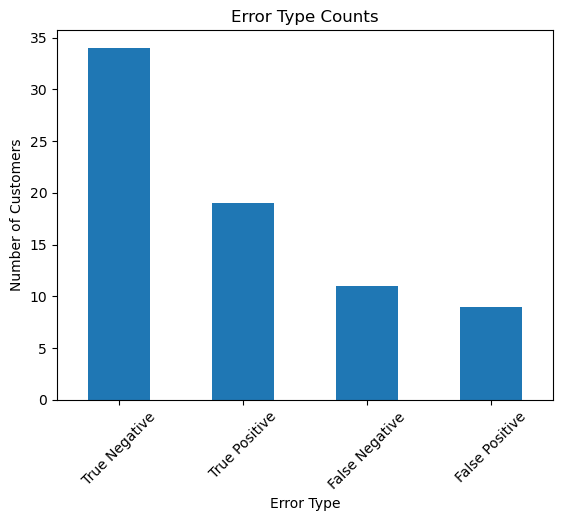

In [29]:
import matplotlib.pyplot as plt

error_counts.plot(
    x="Error Type",
y="Count", kind="bar", legend=False
)

plt.title("Error Type Counts")

plt.xlabel("Error Type")

plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.show()

In [30]:
#Task - 9: Cross Validation

from sklearn.model_selection import cross_val_score

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

cv_results = pd.DataFrame({
    "Fold": ["Fold 1", "Fold 2", "Fold 3", "Fold 4", "Fold 5"],
    "Accuracy": cv_scores
})

cv_results

,Fold,Accuracy
0,Fold 1,0.753425
1,Fold 2,0.694444
2,Fold 3,0.750000
3,Fold 4,0.680556
4,Fold 5,0.736111


In [31]:
mean_cv_accuracy = cv_scores.mean()

std_cv_accuracy = cv_scores.std()

cv_summary = pd.DataFrame({
    "Metric": ["Mean Cross-Validation Accuracy", "Standard Deviation"],
    "Value": [mean_cv_accuracy, std_cv_accuracy]
})

cv_summary

,Metric,Value
0,Mean Cross-Validation Accuracy,0.722907
1,Standard Deviation,0.029811


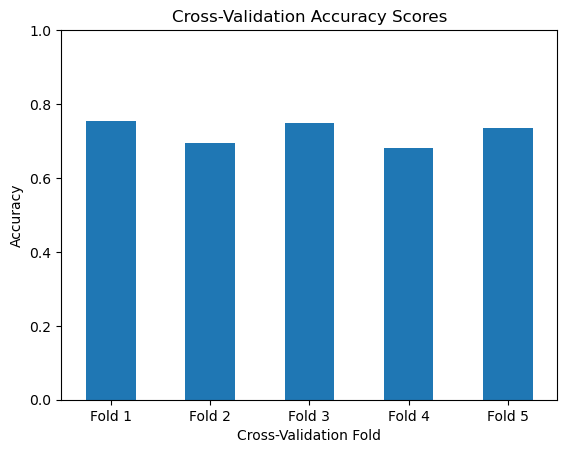

In [32]:
import matplotlib.pyplot as plt

cv_results.plot(
    x="Fold",
y="Accuracy", kind="bar", legend=False
)

plt.title("Cross-Validation Accuracy Scores")

plt.xlabel("Cross-Validation Fold")

plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.xticks(rotation=0)

plt.show()

In [33]:
#Task - 10: Overfitting & Underfitting Analysis

import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score

df = pd.read_csv("small_business_invoice_late_payment_dataset.csv")

y = df["invoice_paid_late"]

X = df.drop(columns=["invoice_id", "invoice_paid_late"])

X = X.drop(columns=["age_group", "gender", "region"])

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = DecisionTreeClassifier(max_depth=4, random_state=42) 
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test) 
train_accuracy = accuracy_score(y_train, y_train_pred) 
test_accuracy = accuracy_score(y_test, y_test_pred)

overfitting_check = pd.DataFrame({
    "Dataset": ["Training Data", "Testing Data"],
    "Accuracy": [train_accuracy, test_accuracy]
})

overfitting_check

,Dataset,Accuracy
0,Training Data,0.807432
1,Testing Data,0.716216


In [34]:
from sklearn.tree import DecisionTreeClassifier

depth_results = []

for depth in range(1, 11):
    
        temp_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
        
        temp_model.fit(X_train, y_train)
        
        train_pred = temp_model.predict(X_train) # Predict values for the testing data
        
        test_pred = temp_model.predict(X_test) # Calculate training accurac
        
        train_acc = accuracy_score(y_train, train_pred) # Calculate testing accuracy
        
        test_acc = accuracy_score(y_test, test_pred)
        
        depth_results.append([depth, train_acc, test_acc])
        
        depth_results_df = pd.DataFrame(
            depth_results,
            columns=["Max Depth", "Training Accuracy", "Testing Accuracy"]
)

depth_results_df

,Max Depth,Training Accuracy,Testing Accuracy
0,1,0.726351,0.756757
1,2,0.733108,0.770270
2,3,0.810811,0.729730
3,4,0.807432,0.716216
4,5,0.854730,0.702703
5,6,0.918919,0.743243
6,7,0.935811,0.716216
7,8,0.935811,0.770270
8,9,0.922297,0.729730
9,10,0.935811,0.770270


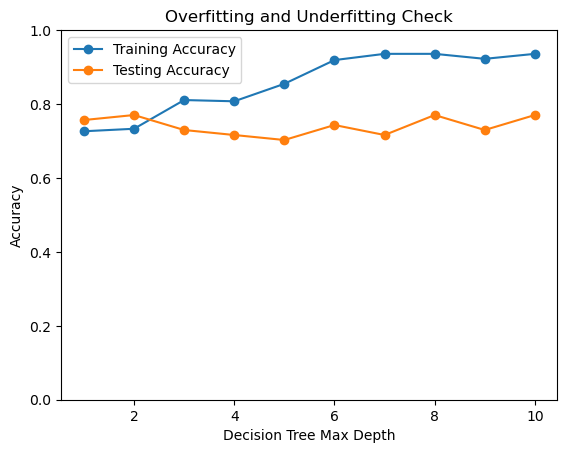

In [35]:
import matplotlib.pyplot as plt

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Training Accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    depth_results_df["Max Depth"],
    depth_results_df["Testing Accuracy"],
    marker="o",
    label="Testing Accuracy"
)

plt.title("Overfitting and Underfitting Check") 
plt.xlabel("Decision Tree Max Depth")
plt.ylabel("Accuracy")

plt.ylim(0, 1)

plt.legend()

plt.show()

In [36]:
#Task 11: Feature Importance 

feature_importance_values = model.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importance_values
})

feature_importance_df = feature_importance_df.sort_values( by="Importance",
ascending=False
)

feature_importance_df

,Feature,Importance
1,invoice_amount,0.345441
3,previous_late_invoices,0.333126
4,number_of_previous_invoices,0.147646
6,client_satisfaction_score,0.086015
5,days_since_last_invoice,0.047752
2,payment_terms_days,0.024282
18,auto_payment_enabled_Yes,0.018719
9,client_type_New,0.004735
8,client_type_Long-term,0.000000
10,client_type_Returning,0.000000


In [37]:
top_features = feature_importance_df.head(10)

top_features

,Feature,Importance
1,invoice_amount,0.345441
3,previous_late_invoices,0.333126
4,number_of_previous_invoices,0.147646
6,client_satisfaction_score,0.086015
5,days_since_last_invoice,0.047752
2,payment_terms_days,0.024282
18,auto_payment_enabled_Yes,0.018719
9,client_type_New,0.004735
8,client_type_Long-term,0.000000
10,client_type_Returning,0.000000


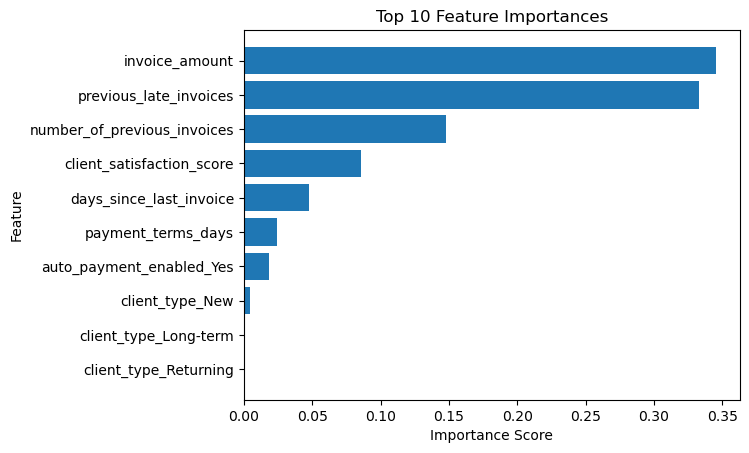

In [38]:
import matplotlib.pyplot as plt

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Feature Importances") 
plt.xlabel("Importance Score") 
plt.ylabel("Feature")

plt.gca().invert_yaxis()

plt.show()

In [39]:
!pip install numpy==1.23.5

  Obtaining dependency information for numpy==1.23.5 from https://files.pythonhosted.org/packages/6e/7f/94797cfe0263a30805f3074e535adfde02b885ac43d1e4dac85f82213b0b/numpy-1.23.5-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Using cached numpy-1.23.5-cp311-cp311-macosx_10_9_x86_64.whl.metadata (2.3 kB)
Using cached numpy-1.23.5-cp311-cp311-macosx_10_9_x86_64.whl (18.1 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tables 3.8.0 requires blosc2~=2.0.0, which is not installed.
tables 3.8.0 requires cython>=0.29.21, which is not installed.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.


In [44]:
!pip uninstall -y numpy scipy shap

Found existing installation: numpy 1.23.5
Uninstalling numpy-1.23.5:
  Successfully uninstalled numpy-1.23.5
Found existing installation: scipy 1.17.1
Uninstalling scipy-1.17.1:
  Successfully uninstalled scipy-1.17.1
Found existing installation: shap 0.51.0
Uninstalling shap-0.51.0:
  Successfully uninstalled shap-0.51.0


In [45]:
!pip install numpy==1.26.4 scipy==1.11.4 shap

  Obtaining dependency information for numpy==1.26.4 from https://files.pythonhosted.org/packages/11/57/baae43d14fe163fa0e4c47f307b6b2511ab8d7d30177c491960504252053/numpy-1.26.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 893.8 kB/s eta 0:00:00 0:00:01
  Obtaining dependency information for scipy==1.11.4 from https://files.pythonhosted.org/packages/b8/f2/1aefbd5e54ebd8c6163ccf7f73e5d17bc8cb38738d312befc524fce84bb4/scipy-1.11.4-cp311-cp311-macosx_10_9_x86_64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 1.8 MB/s eta 0:00:00
  Obtaining dependency information for shap from https://files.pythonhosted.org/packages/1b/4f/513ffc1c27242488be2269d5704c7bd8e82c6b28a04c297533d616003948/shap-0.51.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata
  Using cached shap-0.51.0-cp311-cp311-macosx_10_9_x86_64.whl.metadata (25 kB)
INFO: pip is looking at multiple versions of shap to determine which version is compatible with 

In [40]:
import shap

import matplotlib.pyplot as plt

shap.initjs()

In [41]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

type(shap_values)

numpy.ndarray

In [45]:
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1]

base_value_class1 = explainer.expected_value[1]

shap_values_class1.shape

(74, 19)

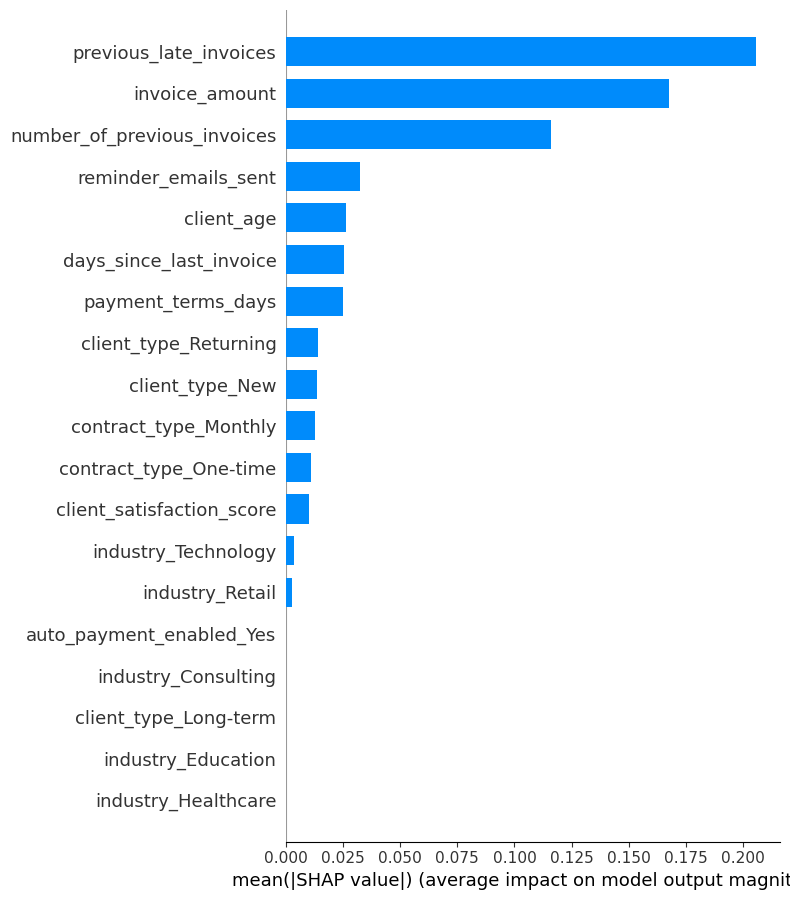

In [46]:
shap.summary_plot(
    shap_values_class1,
    X_test,
    plot_type="bar"
)

In [49]:
invoice_index = 0

invoice_data = X_test.iloc[invoice_index]

invoice_shap_values = shap_values_class1[invoice_index]

invoice_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Feature Value": invoice_data.values,
    "SHAP Value": invoice_shap_values
})

invoice_explanation["Absolute SHAP Value"] = invoice_explanation["SHAP Value"].abs()

invoice_explanation = invoice_explanation.sort_values( by="Absolute SHAP Value",
ascending=False
)

invoice_explanation.head(10)

,Feature,Feature Value,SHAP Value,Absolute SHAP Value
3,previous_late_invoices,1,-0.127345,0.127345
4,number_of_previous_invoices,44,-0.097886,0.097886
1,invoice_amount,8554.27,-0.094314,0.094314
2,payment_terms_days,14,0.026344,0.026344
5,days_since_last_invoice,296,-0.019339,0.019339
7,reminder_emails_sent,0,-0.013040,0.013040
17,contract_type_One-time,True,0.005962,0.005962
0,client_age,51,0.004179,0.004179
6,client_satisfaction_score,5,-0.002749,0.002749
10,client_type_Returning,True,0.002339,0.002339


In [50]:
#Task 13: LIME Explanation

!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 3.7 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283839 sha256=4e7be1f8e57e5128c3e4fffd7258a74ef36f5bd7777da8b38bfe834b50e109ae
  Stored in directory: /Users/sheezatoor/Library/Caches/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from lime.lime_tabular import LimeTabularExplainer

In [52]:
X_train_lime = X_train.astype(float)

X_test_lime = X_test.astype(float) 

feature_names = X_train_lime.columns.tolist()

class_names = ["Not Late Payment", "Late Payment"]

In [53]:
lime_explainer = LimeTabularExplainer(
    
    training_data=X_train_lime.values, 
    feature_names=feature_names,
    class_names=class_names,
    mode="classification",
    discretize_continuous=True
)

In [54]:
invoice_index = 0

invoice_instance = X_test_lime.iloc[invoice_index]

invoice_instance

client_age                       51.00
invoice_amount                 8554.27
payment_terms_days               14.00
previous_late_invoices            1.00
number_of_previous_invoices      44.00
days_since_last_invoice         296.00
client_satisfaction_score         5.00
reminder_emails_sent              0.00
client_type_Long-term             0.00
client_type_New                   0.00
client_type_Returning             1.00
industry_Consulting               0.00
industry_Education                0.00
industry_Healthcare               1.00
industry_Retail                   0.00
industry_Technology               0.00
contract_type_Monthly             0.00
contract_type_One-time            1.00
auto_payment_enabled_Yes          1.00
Name: 21, dtype: float64

In [59]:
lime_explainer = LimeTabularExplainer(
    training_data=X_train,
    feature_names=feature_names,
    mode="classification",
    discretize_continuous=False
)

lime_explanation = lime_explainer.explain_instance(
    data_row=invoice_instance.values,
    predict_fn=model.predict_proba,
    num_features=10
)

/Users/sheezatoor/anaconda3/lib/python3.11/site-packages/sklearn/base.py:464: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [60]:
actual_value = y_test.iloc[invoice_index]

predicted_value = model.predict(X_test_lime.iloc[[invoice_index]])[0]

predicted_probabilities = model.predict_proba(X_test_lime.iloc[[invoice_index]])[0]

lime_prediction_result = pd.DataFrame({
    "Actual Late Payment": [actual_value],
    "Predicted Late Payment": [predicted_value],
    "Probability of Not Late Payment": [predicted_probabilities[0]],
    "Probability of Late Payment": [predicted_probabilities[1]]
})

lime_prediction_result

,Actual Late Payment,Predicted Late Payment,Probability of Not Late Payment,Probability of Late Payment
0,0,0,0.904762,0.095238


In [61]:
lime_explanation_table = pd.DataFrame(
    lime_explanation.as_list(),
    columns=["Feature Condition", "Contribution"]
)

lime_explanation_table

,Feature Condition,Contribution
0,invoice_amount,0.159945
1,number_of_previous_invoices,-0.103803
2,days_since_last_invoice,-0.047835
3,payment_terms_days,-0.032473
4,reminder_emails_sent,0.018811
5,industry_Healthcare,-0.017061
6,contract_type_One-time,0.013323
7,client_type_Returning,0.003713
8,contract_type_Monthly,0.003198
9,auto_payment_enabled_Yes,-0.001462


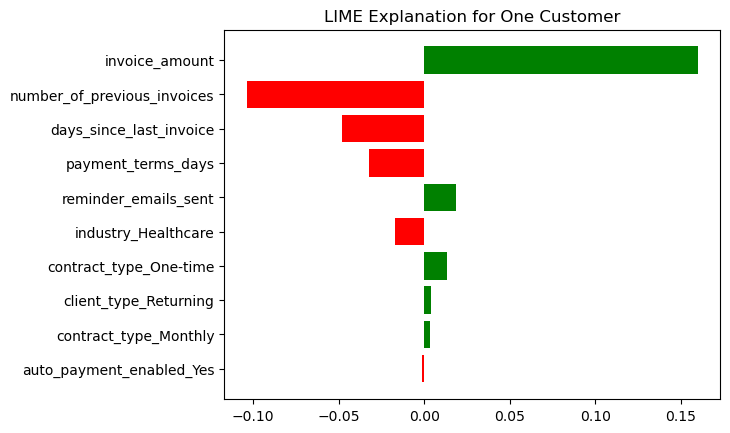

In [62]:
fig = lime_explanation.as_pyplot_figure() 

plt.title("LIME Explanation for One Customer")

plt.show()

In [63]:
from IPython.display import display, HTML

lime_html = lime_explanation.as_html()

display(HTML(lime_html))

In [64]:
#Task 14 - Fairness & Bias Reflection

y_test_pred = model.predict(X_test)

fairness_data = df.loc[y_test.index, ["invoice_id", "gender", "age_group", "region"]].copy()

fairness_data["Actual Late Payment"] = y_test.values

fairness_data["Predicted Late Payment"] = y_test_pred

fairness_data["Correct Prediction"] = fairness_data["Actual Late Payment"] == fairness_data["Predicted Late Payment"]

fairness_data.head(10)

,invoice_id,gender,age_group,region,Actual Late Payment,Predicted Late Payment,Correct Prediction
21,INV0022,Female,51+,South,0,0,True
93,INV0094,Female,51+,West,0,0,True
203,INV0204,Female,51+,North,1,1,True
149,INV0150,Male,51+,East,0,0,True
184,INV0185,Male,36-50,East,0,0,True
1,INV0002,Male,51+,South,0,0,True
10,INV0011,Female,36-50,North,1,1,True
112,INV0113,Female,51+,North,1,0,False
191,INV0192,Male,51+,North,1,1,True
295,INV0296,Female,26-35,North,0,1,False


In [68]:
def fairness_summary(group_column):
    summary = fairness_data.groupby(group_column).agg(
        Number_of_Invoices=("invoice_id", "count"),
        Actual_Late_Payment_Rate=("Actual Late Payment", "mean"),
        Predicted_Late_Payment_Rate=("Predicted Late Payment", "mean"),
        Accuracy=("Correct Prediction", "mean")
    ).reset_index()
    return summary

In [69]:
gender_fairness = fairness_summary("gender")
gender_fairness

,gender,Number_of_Invoices,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,Female,37,0.378378,0.459459,0.594595
1,Male,37,0.459459,0.243243,0.729730


In [70]:
age_group_fairness = fairness_summary("age_group")
age_group_fairness

,age_group,Number_of_Invoices,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,18-25,2,0.500000,0.000000,0.500000
1,26-35,16,0.562500,0.375000,0.437500
2,36-50,22,0.318182,0.409091,0.818182
3,51+,34,0.411765,0.323529,0.676471


In [71]:
region_fairness = fairness_summary("region")
region_fairness

,region,Number_of_Invoices,Actual_Late_Payment_Rate,Predicted_Late_Payment_Rate,Accuracy
0,East,12,0.250000,0.333333,0.583333
1,North,23,0.391304,0.478261,0.565217
2,South,21,0.333333,0.238095,0.809524
3,West,18,0.666667,0.333333,0.666667


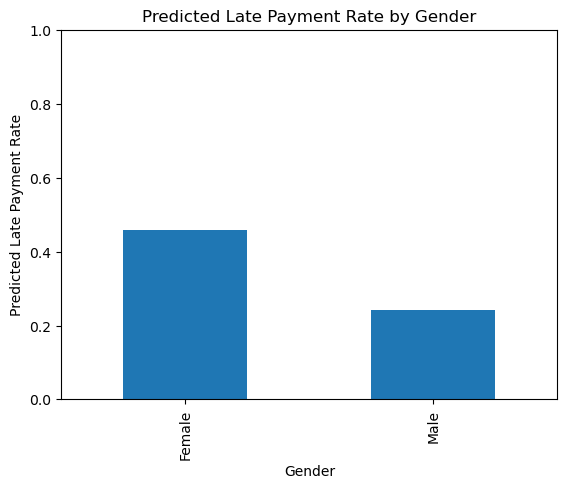

In [72]:
gender_fairness.plot(
    x="gender",
y="Predicted_Late_Payment_Rate", kind="bar",
legend=False
)

plt.title("Predicted Late Payment Rate by Gender")

plt.xlabel("Gender")
plt.ylabel("Predicted Late Payment Rate") 
plt.ylim(0, 1)
plt.show()

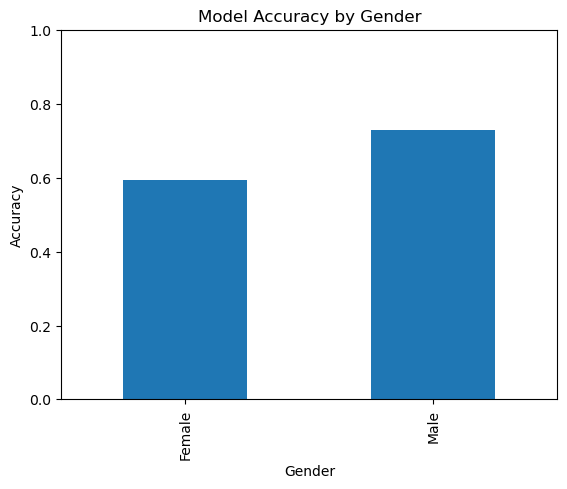

In [74]:
gender_fairness.plot(
    x="gender",
    y="Accuracy",
    kind="bar",
    legend=False 
)
plt.title("Model Accuracy by Gender") 
plt.xlabel("Gender")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.show()

In [76]:
#Task 15: Final Business Interpretation

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

y_train_pred = model.predict(X_train)

y_test_pred = model.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)

test_accuracy = accuracy_score(y_test, y_test_pred) 

precision = precision_score(y_test, y_test_pred, zero_division=0) 

recall = recall_score(y_test, y_test_pred, zero_division=0)

f1 = f1_score(y_test, y_test_pred, zero_division=0) 

cm = confusion_matrix(y_test, y_test_pred)

tn, fp, fn, tp = cm.ravel()

business_summary = pd.DataFrame({
    "Result": [
        "Training Accuracy",
        "Testing Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ], 
    "Value": [
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        tn,
        fp,
        fn,
        tp
    ]})
    
business_summary

,Result,Value
0,Training Accuracy,0.902027
1,Testing Accuracy,0.662162
2,Precision,0.615385
3,Recall,0.516129
4,F1-Score,0.561404
5,True Negative,33.000000
6,False Positive,10.000000
7,False Negative,15.000000
8,True Positive,16.000000
